Ari Mononen - Neural Networks for Computer Vision

In [3]:
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.metrics import classification_report, confusion_matrix
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
from tempfile import TemporaryDirectory
import math

cudnn.benchmark = True
plt.ion()

In [4]:
print("CUDA saatavilla:", torch.cuda.is_available())
print("PyTorch-versio:", torch.__version__)

CUDA saatavilla: False
PyTorch-versio: 2.14.0+cpu


In [5]:
# Data-augmentaatio ja normalisointi opetussetille (estää ylisovittamista / overfitting).
# Validointi- ja testitestille tehdään vain muodon muutos ja normalisointi reilun arvioinnin takaamiseksi.

data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(299), # Nostetaan resoluutio 299x299 pikkutarkkojen yksityiskohtien (kuten lehtisuonten) erottamiseksi
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(degrees=15), # Lisätty satunnainen rotaatio (-15 ... +15 astetta) asentovaihtelun simuloimiseksi 
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1), # Lisätty värisävyjen, kirkkauden ja kontrastin hienosäätö eri valaistusolosuhteiden simulointiin
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(320), # Skaalataan hieman 299 pikseliä suuremmaksi ennen keskeltä rajausta
        transforms.CenterCrop(299), # Rajataan täsmälleen 299x299 kokoon
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize(320),
        transforms.CenterCrop(299),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}

# Datasetti on jaettu train, val ja test osuuksiin jo valmiiksi
data_dir = 'tree'
splits = ['train', 'val', 'test']

# Ladataan kuva-aineisto kansiorakenteen perusteella
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          data_transforms[x])
                  for x in splits}

# Luodaan Dataloader-olion, jotka syöttävät dataa batcheissä mallille
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=32,
                                             shuffle=(x == 'train'), num_workers=4)
              for x in splits}

dataset_sizes = {x: len(image_datasets[x]) for x in splits}
class_names = image_datasets['train'].classes

# Valitaan suoritin: GPU (CUDA), jos saatavilla, muuten CPU
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")
print(f"Löytyi {len(class_names)} luokkaa.")

Using cpu device
Löytyi 23 luokkaa.


In [6]:
def imshow(inp, title=None):
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)

In [7]:
# Tämä funktio kouluttaa neuroverkkomallin ja tallentaa parhaan val-tarkkuuden saavuttaneet painoarvot.

def train_model(model, criterion, optimizer, scheduler, num_epochs=10):
    since = time.time()

    # Käytetään väliaikaishakemistoa parhaan mallin painojen tallentamiseen koulutuksen aikana
    with TemporaryDirectory() as tempdir:
        best_model_params_path = os.path.join(tempdir, 'best_model_params.pt')

        torch.save(model.state_dict(), best_model_params_path)
        best_acc = 0.0

        for epoch in range(num_epochs):
            print(f'Epoch {epoch}/{num_epochs - 1}')
            print('-' * 10)

            # Jokainen epookki sisältää opetus- ja valintavaiheen
            for phase in ['train', 'val']:
                if phase == 'train':
                    model.train()  # Asettaa mallin opetustilaan
                else:
                    model.eval()   # Asettaa mallin arviointitilaan

                running_loss = 0.0
                running_corrects = 0

                # Käydään läpi kaikki datasetin erät (batches)
                for inputs, labels in dataloaders[phase]:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    # Nollataan gradientit ennen uutta laskentakierrosta
                    optimizer.zero_grad()

                    # Gradienttien laskenta suoritetaan vain opetusvaiheessa muistin säästämiseksi
                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                        # Takaisinlevitys (backpropagation) ja optimointi vain opetustilassa
                        if phase == 'train':
                            loss.backward()
                            optimizer.step()

                    # Tilastot
                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)

                # Päivitetään learning ratea opetusepookin jälkeen
                if phase == 'train':
                    scheduler.step()

                epoch_loss = running_loss / dataset_sizes[phase]
                epoch_acc = running_corrects.double() / dataset_sizes[phase]

                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

                # Jos val-tarkkuus on paras tähän asti, tallennetaan mallin painot
                if phase == 'val' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), best_model_params_path)

            print()

        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:4f}')

        model.load_state_dict(torch.load(best_model_params_path, weights_only=True))
    return model

In [8]:
# Visualisoi mallin tekemiä ennusteita. Muuntaa normalisoidut pytorch-tensorit takaisin katselukelpoisiksi kuviksi.

def visualize_model(model, num_images=23, split='val'):
    was_training = model.training
    model.eval()
    images_so_far = 0

    # Laitetaan kuvat 5 sarakkeeseen (23 kuvalle tulee 5 riviä)
    cols = 5
    rows = math.ceil(num_images / cols)
    fig = plt.figure(figsize=(10, 3 * rows))

    # Mean ja std kuvan palauttamiseksi normaaliksi
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders[split]):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(rows, cols, images_so_far)
                ax.axis('off')
                ax.set_title(f'pred: {class_names[preds[j]]}', fontsize=8)

                # Kuvan un-normalisointi ja piirto suoraan ruutuun
                inp = inputs.cpu().data[j].numpy().transpose((1, 2, 0))
                inp = std * inp + mean
                inp = np.clip(inp, 0, 1)
                ax.imshow(inp)

                if images_so_far == num_images:
                    plt.tight_layout()
                    plt.show()
                    model.train(mode=was_training)
                    return
                    
        plt.tight_layout()
        plt.show()
        model.train(mode=was_training)

In [9]:
# Laskee mallille monipuoliset suorituskykymetriikat testisetistä:
# - Classification Report (Precision, Recall, F1-score)
# - Confusion Matrix
# - Top-N Accuracy (Kuinka usein oikea luokka on N parhaan ennusteen joukossa)

from sympy import Matrix


def evaluate_model_on_test(model, split='test', topk_values=(1, 2, 3, 5)):
    model.eval()

    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for inputs, labels in dataloaders[split]:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            probs = F.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.append(probs.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.vstack(all_probs)

    # 1. Perusmetriikat (Accuracy, Precision, Recall, F1)
    print("=== CLASSIFICATION REPORT ===")
    print(
        classification_report(
            all_labels, all_preds, target_names=class_names, digits=4
        )
    )

    # 2. Confusion Matrix
    print("=== CONFUSION MATRIX ===")
    cm = confusion_matrix(all_labels, all_preds)
    print(cm)




    # 3. Top-N tulokset
    print("\n=== TOP-N ACCURACIES ===")
    for k in topk_values:
        # Tarkistetaan löytyykö oikea luokka top-k ennusteista
        topk_preds = np.argsort(all_probs, axis=1)[:, -k:]
        correct = sum(
            [
                all_labels[i] in topk_preds[i]
                for i in range(len(all_labels))
            ]
        )
        topk_acc = correct / len(all_labels)
        print(f'Top-{k} Accuracy: {topk_acc:.4f}')





# ResNet18-malli:

In [10]:
# Transfer Learning ja ResNet18-mallin alustus:

# Ladataan valmiiksi koulutettu ResNet18-malli
model_resnet18 = models.resnet18(weights='IMAGENET1K_V1')

# Vaihdetaan mallin viimeinen fully connected kerros vastaamaan oman aineistomme 23:a luokkamäärää
num_ftrs = model_resnet18.fc.in_features
model_resnet18.fc = nn.Linear(num_ftrs, len(class_names))

# Siirretään malli laskentalaitteelle
model_resnet18 = model_resnet18.to(device)

# Määritetään loss function, optimizer ja learning rate
criterion = nn.CrossEntropyLoss()
optimizer_resnet18 = optim.SGD(model_resnet18.parameters(), lr=0.001, momentum=0.9)
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_resnet18, step_size=7, gamma=0.1)

In [18]:
# ResNet18-mallin koulutus:

model_resnet18 = train_model(model_resnet18, criterion, optimizer_resnet18, exp_lr_scheduler,
                       num_epochs=10)

Epoch 0/9
----------
train Loss: 2.9024 Acc: 0.1540
val Loss: 2.2679 Acc: 0.3921

Epoch 1/9
----------
train Loss: 2.1254 Acc: 0.4023
val Loss: 1.4121 Acc: 0.5996

Epoch 2/9
----------
train Loss: 1.5400 Acc: 0.5629
val Loss: 1.0452 Acc: 0.6867

Epoch 3/9
----------
train Loss: 1.2494 Acc: 0.6332
val Loss: 0.7847 Acc: 0.7759

Epoch 4/9
----------
train Loss: 1.0650 Acc: 0.6930
val Loss: 0.8813 Acc: 0.7344

Epoch 5/9
----------
train Loss: 0.9511 Acc: 0.7200
val Loss: 0.5825 Acc: 0.8112

Epoch 6/9
----------
train Loss: 0.8664 Acc: 0.7444
val Loss: 0.5525 Acc: 0.8195

Epoch 7/9
----------
train Loss: 0.7724 Acc: 0.7738
val Loss: 0.4382 Acc: 0.8651

Epoch 8/9
----------
train Loss: 0.7382 Acc: 0.7857
val Loss: 0.4250 Acc: 0.8631

Epoch 9/9
----------
train Loss: 0.7412 Acc: 0.7818
val Loss: 0.4274 Acc: 0.8672

Training complete in 22m 49s
Best val Acc: 0.867220


In [11]:
# Ajo ResNet-18:sta

print("---------------- ResNet-18 TEST TULOKSET ----------------")
evaluate_model_on_test(model_resnet18, split='test')

---------------- ResNet-18 TEST TULOKSET ----------------
=== CLASSIFICATION REPORT ===
                                   precision    recall  f1-score   support

                    Acer palmatum     0.0625    0.0500    0.0556        20
                   Cedrus deodara     0.0000    0.0000    0.0000        15
                  Celtis sinensis     0.0000    0.0000    0.0000        23
 Cinnamomum camphora (Linn) Presl     0.0000    0.0000    0.0000        29
            Elaeocarpus decipiens     0.0000    0.0000    0.0000        21
                 Flowering cherry     0.0000    0.0000    0.0000        13
                    Ginkgo biloba     0.0000    0.0000    0.0000        28
          Koelreuteria paniculata     0.0000    0.0000    0.0000        28
             Lagerstroemia indica     0.0000    0.0000    0.0000         8
            Liquidambar formosana     0.0000    0.0000    0.0000        20
            Liriodendron chinense     0.0000    0.0000    0.0000        22
           

c:\Users\Frans\.conda\envs\nn_env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Frans\.conda\envs\nn_env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Frans\.conda\envs\nn_env\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


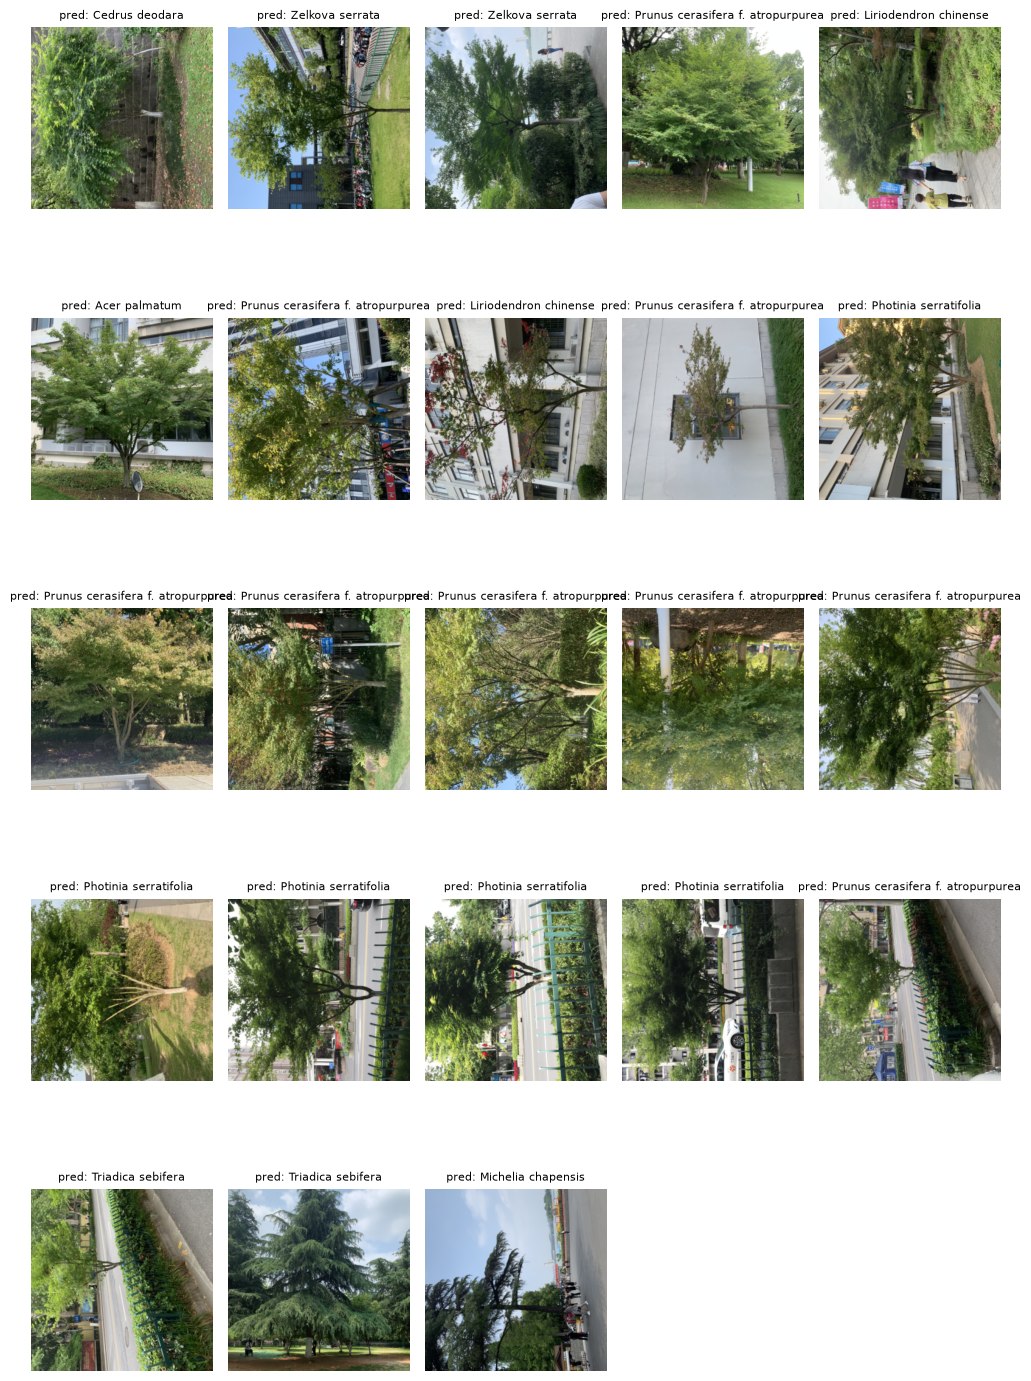

In [12]:
# Printtaa 23 kuvaa ResNet18-mallin validation-setistä:

visualize_model(model_resnet18, num_images=23, split='val')

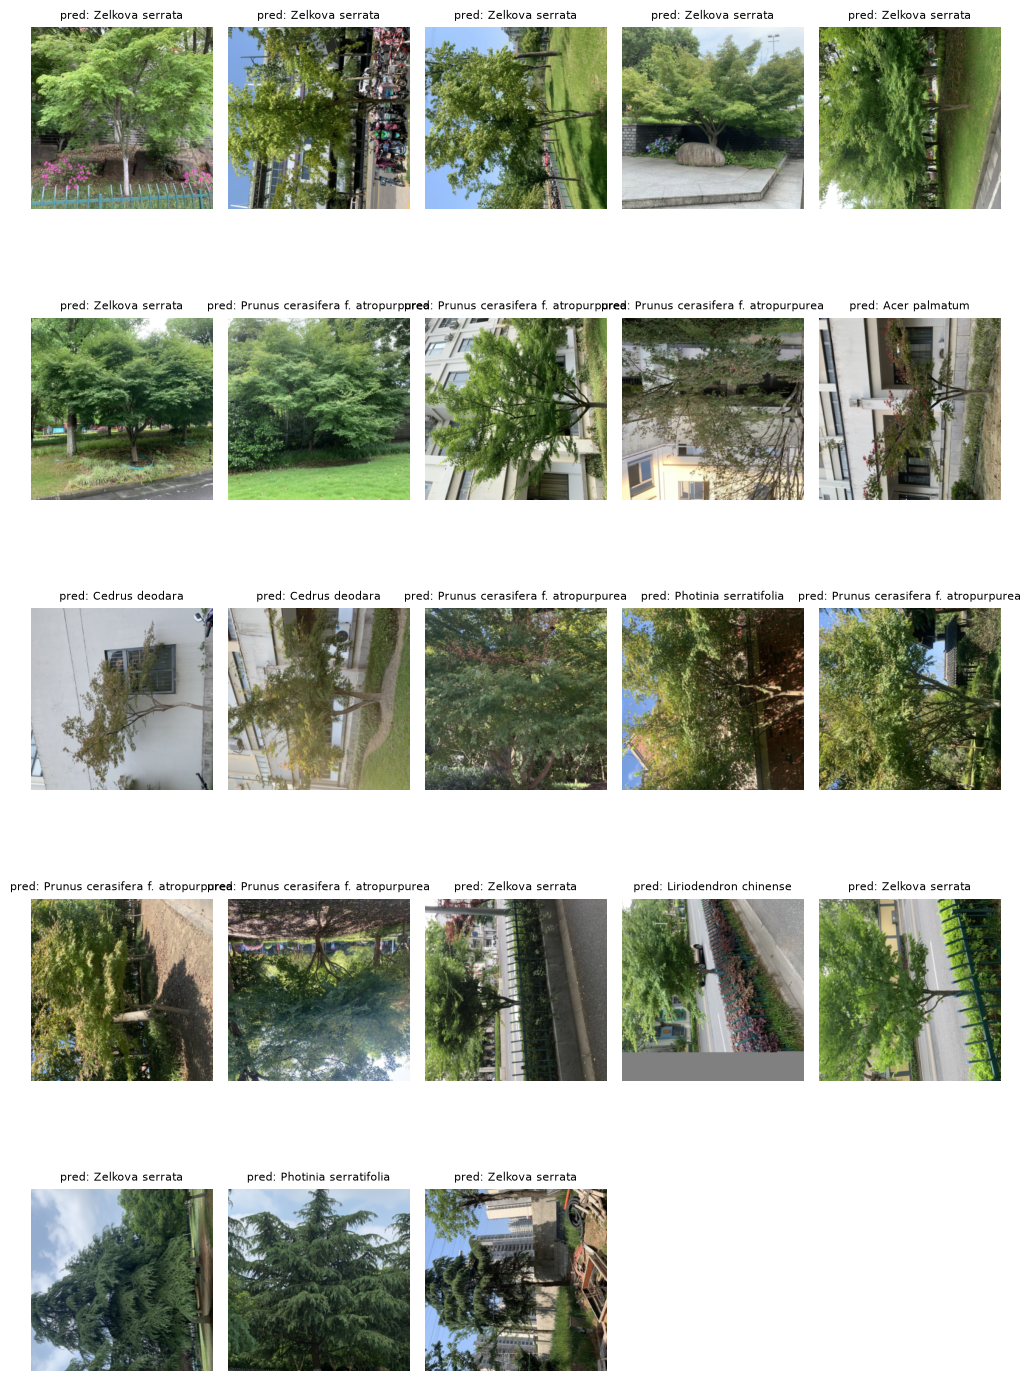

In [13]:
# Printtaa 23 kuvaa ResNet18-mallin test-setistä:

visualize_model(model_resnet18, num_images=23, split='test')

# ResNet50-malli:

In [14]:
# Transfer Learning ja ResNet50-mallin alustus:

# Ladataan valmiiksi koulutettu ResNet50-malli
model_resnet50 = models.resnet50(weights='IMAGENET1K_V1')

# Vaihdetaan mallin viimeinen fully connected kerros vastaamaan oman aineistomme 23:a luokkamäärää
num_ftrs = model_resnet50.fc.in_features
model_resnet50.fc = nn.Linear(num_ftrs, len(class_names))

# Siirretään malli laskentalaitteelle
model_resnet50 = model_resnet50.to(device)

# Määritetään loss function, optimizer ja learning rate
criterion = nn.CrossEntropyLoss()
optimizer_resnet50 = optim.SGD(model_resnet50.parameters(), lr=0.001, momentum=0.9)
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_resnet50, step_size=7, gamma=0.1)

In [23]:
# ResNet50-mallin koulutus:

model_resnet50 = train_model(model_resnet50, criterion, optimizer_resnet50,
                         exp_lr_scheduler, num_epochs=10)

Epoch 0/9
----------
train Loss: 2.8646 Acc: 0.1803
val Loss: 2.1513 Acc: 0.4710

Epoch 1/9
----------
train Loss: 1.9191 Acc: 0.4792
val Loss: 1.1894 Acc: 0.6763

Epoch 2/9
----------
train Loss: 1.3544 Acc: 0.6117
val Loss: 0.8447 Acc: 0.7697

Epoch 3/9
----------
train Loss: 1.0339 Acc: 0.7068
val Loss: 0.6596 Acc: 0.8195

Epoch 4/9
----------
train Loss: 0.8634 Acc: 0.7488
val Loss: 0.5036 Acc: 0.8361

Epoch 5/9
----------
train Loss: 0.7165 Acc: 0.8000
val Loss: 0.3672 Acc: 0.8963

Epoch 6/9
----------
train Loss: 0.6119 Acc: 0.8229
val Loss: 0.5004 Acc: 0.8506

Epoch 7/9
----------
train Loss: 0.5651 Acc: 0.8358
val Loss: 0.3236 Acc: 0.9046

Epoch 8/9
----------
train Loss: 0.5302 Acc: 0.8486
val Loss: 0.3083 Acc: 0.9191

Epoch 9/9
----------
train Loss: 0.5075 Acc: 0.8574
val Loss: 0.3082 Acc: 0.9149

Training complete in 75m 13s
Best val Acc: 0.919087


In [24]:
# Ajo ResNet-50:sta

print("\n---------------- ResNet-50 TEST TULOKSET ----------------")
evaluate_model_on_test(model_resnet50, split='test')


---------------- ResNet-50 TEST TULOKSET ----------------
=== CLASSIFICATION REPORT ===
                                   precision    recall  f1-score   support

                    Acer palmatum     0.8000    0.8000    0.8000        20
                   Cedrus deodara     0.9375    1.0000    0.9677        15
                  Celtis sinensis     0.9412    0.6957    0.8000        23
 Cinnamomum camphora (Linn) Presl     0.9355    1.0000    0.9667        29
            Elaeocarpus decipiens     0.8000    0.7619    0.7805        21
                 Flowering cherry     1.0000    0.4615    0.6316        13
                    Ginkgo biloba     0.8333    0.8929    0.8621        28
          Koelreuteria paniculata     0.8065    0.8929    0.8475        28
             Lagerstroemia indica     0.8750    0.8750    0.8750         8
            Liquidambar formosana     0.9000    0.9000    0.9000        20
            Liriodendron chinense     0.8000    0.9091    0.8511        22
          

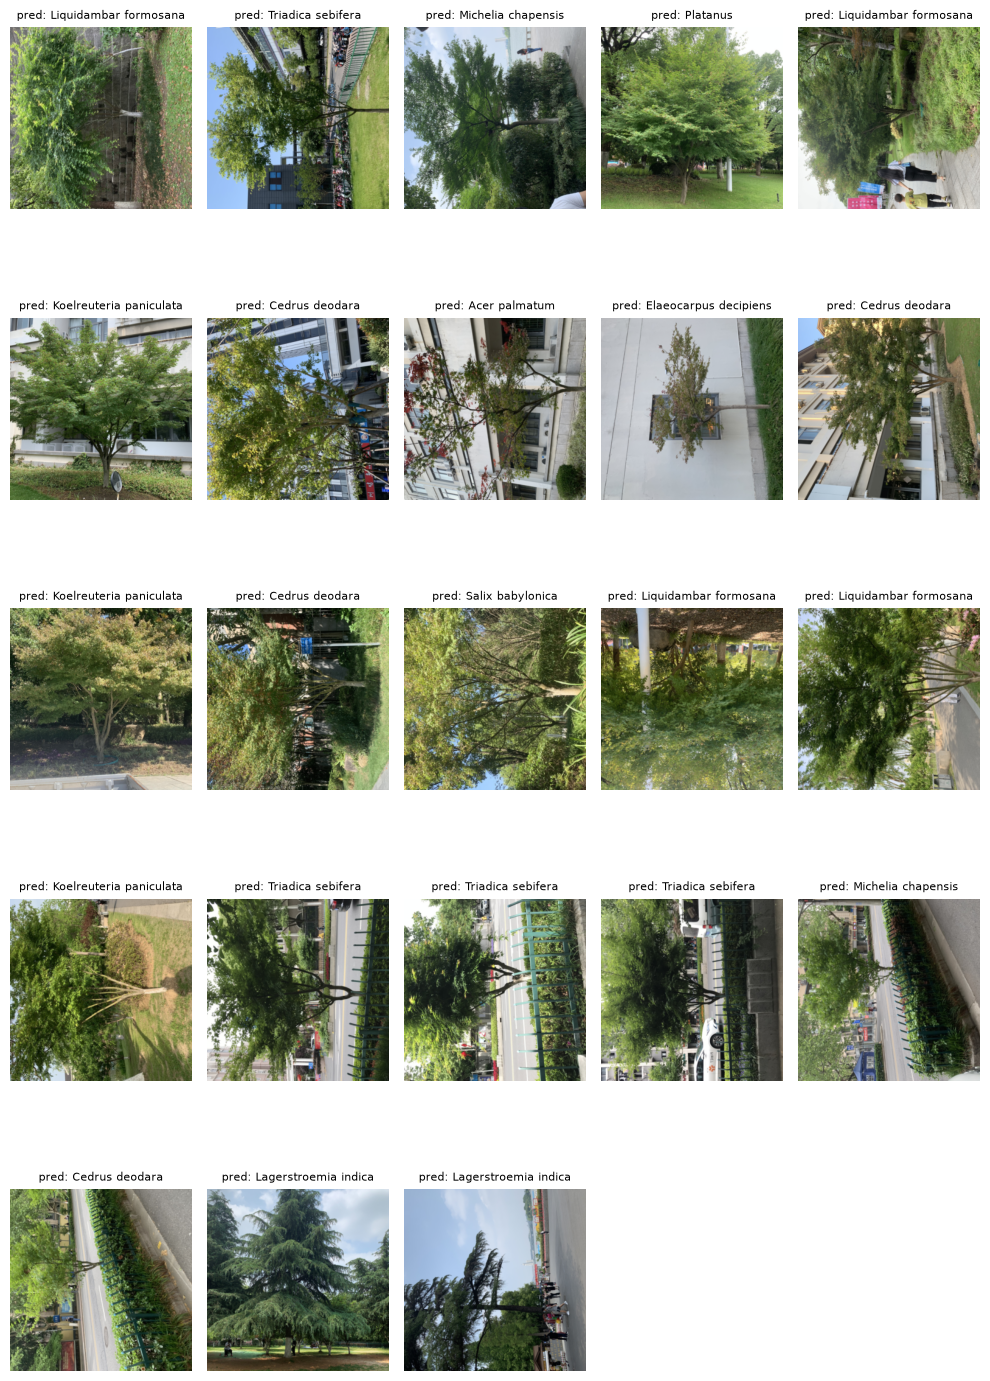

In [15]:
# Printtaa 23 kuvaa ResNet50-mallin validation-setistä:

visualize_model(model_resnet50, num_images=23, split='val')

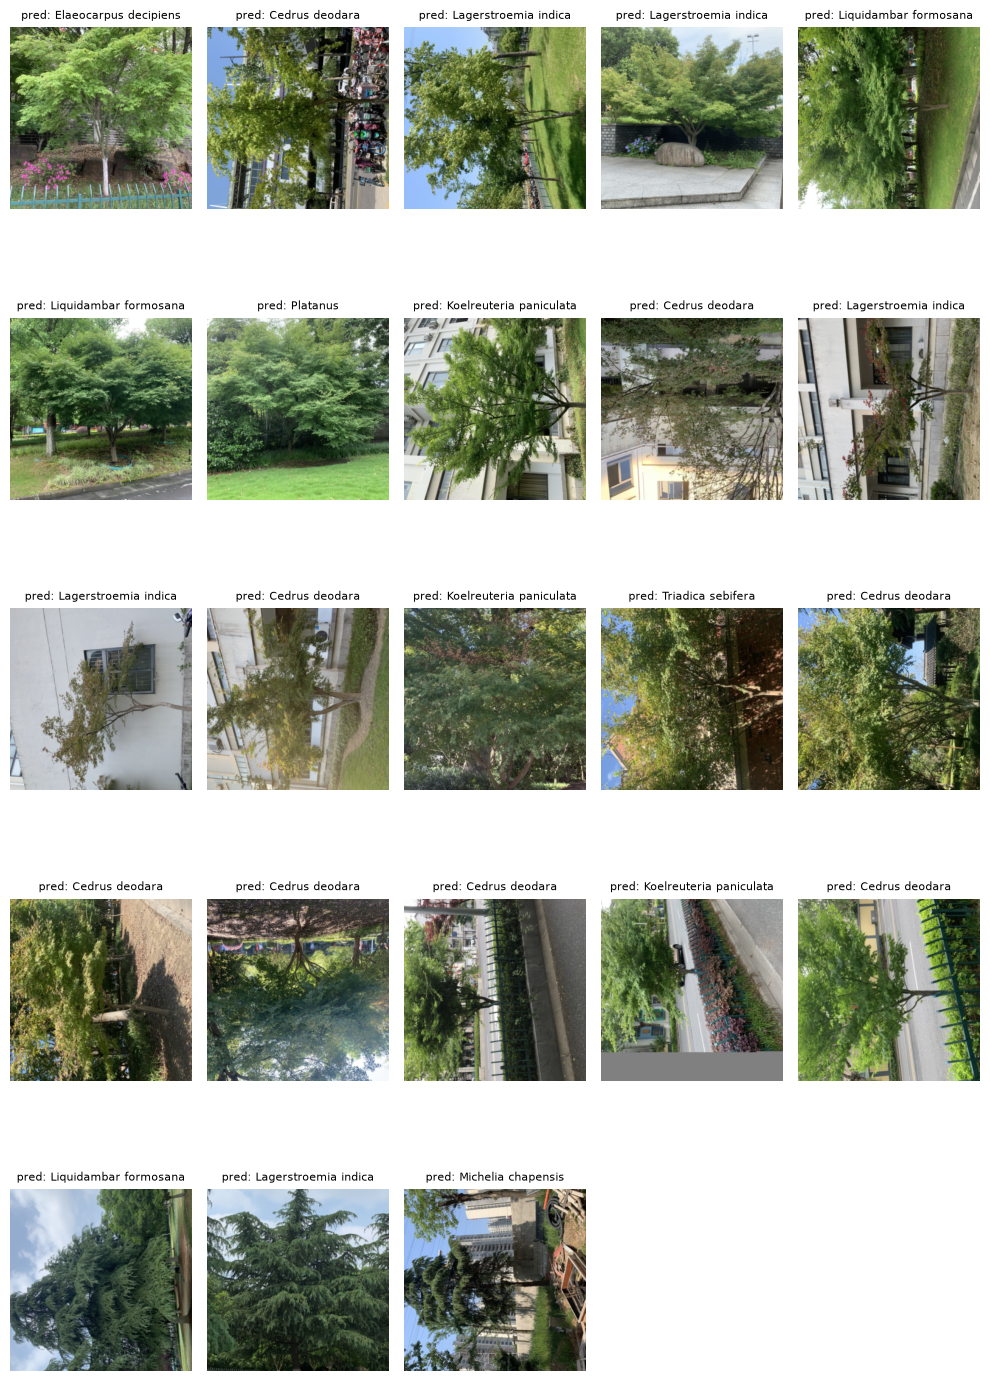

In [16]:
# Printtaa 23 kuvaa ResNet50-mallin test-setistä:

visualize_model(model_resnet50, num_images=23, split='test')